## 207 Modelling

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import tensorflow as tf
from tensorflow import keras
from keras import metrics
tf.get_logger().setLevel('INFO')

In [2]:
# Import Input Datasets
X_train = pd.read_csv('../data/X_train.csv')
X_val = pd.read_csv('../data/X_val.csv')
X_test = pd.read_csv('../data/X_test.csv')

y_train = pd.read_csv('../data/y_train.csv')
y_val = pd.read_csv('../data/y_val.csv')
y_test = pd.read_csv('../data/y_test.csv')


## 0. Use preprocessing (from Kala's notebook)

In [3]:
from rapidfuzz import process, fuzz
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [4]:
# Loading Airbnb DataSet
airbnb_path = "../data/LA_listings.csv"
airbnb = pd.read_csv(airbnb_path)
print("Raw Airbnb shape:", airbnb.shape)
airbnb.head()

C:\Users\Hubert\AppData\Local\Temp\ipykernel_18892\3223180033.py:3: DtypeWarning: Columns (0: host_since) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb = pd.read_csv(airbnb_path)


Raw Airbnb shape: (45533, 26)


,Unnamed: 0,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
0,0,670339032744709144,Westwood lovely three bedrooms three bathrooms,4780152,Moon,20/01/13,within a few hours,0.96,f,West Los Angeles,...,3.0,3.0,3.0,399.0,30,365,0,NaN,NaN,f
1,1,37014494,Spanish style lower duplex near Beverly Hills,278288178,Ida,22/07/19,NaN,NaN,f,Beverlywood,...,NaN,2.0,NaN,NaN,30,0,0,NaN,NaN,f
2,2,1024835174766068422,Charming Beverly Hills Home,513813179,Tiana,08/05/23,within a day,0.60,f,Beverly Hills,...,3.0,3.0,3.0,434.0,30,267,0,NaN,NaN,f
3,3,850744632375448560,Tianpu's warm room with bathroom,432956623,Dan,22/11/21,a few days or more,0.20,f,Temple City,...,1.0,1.0,1.0,49.0,1,364,1,3.00,NaN,f
4,4,953950676345326970,"Santa Monica apt, free parking, steps to the b...",528669205,Farkhat,29/07/23,within an hour,1.00,t,Santa Monica,...,1.0,0.0,1.0,231.0,5,193,44,4.93,Exempt,t


In [5]:
# Loading Zillow DataSet
zillow_path = "../data/neighborhood_zillow.csv"
zillow = pd.read_csv(zillow_path)

print("Raw Zillow shape:", zillow.shape)

zillow.head()

Raw Zillow shape: (21600, 326)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,112345,0,Maryvale,neighborhood,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,70265.246748,...,3.348063e+05,3.334858e+05,3.323610e+05,3.319901e+05,3.322638e+05,3.325127e+05,3.327364e+05,3.325103e+05,3.319002e+05,3.306516e+05
1,192689,1,Paradise,neighborhood,NV,NV,Las Vegas,"Las Vegas-Henderson-Paradise, NV",Clark County,136526.801960,...,4.010091e+05,3.995406e+05,3.983678e+05,3.977305e+05,3.972949e+05,3.969128e+05,3.965360e+05,3.960044e+05,3.954638e+05,3.943812e+05
2,270958,2,Upper West Side,neighborhood,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,409392.009209,...,1.316164e+06,1.314903e+06,1.318541e+06,1.324716e+06,1.329700e+06,1.337544e+06,1.347921e+06,1.355638e+06,1.357036e+06,1.353330e+06
3,270957,3,Upper East Side,neighborhood,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",New York County,666524.848137,...,1.272871e+06,1.278652e+06,1.287203e+06,1.294640e+06,1.298567e+06,1.307315e+06,1.323102e+06,1.337632e+06,1.343938e+06,1.339842e+06
4,118208,4,South Los Angeles,neighborhood,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,134453.790051,...,6.770960e+05,6.801553e+05,6.823887e+05,6.835706e+05,6.853429e+05,6.855409e+05,6.846294e+05,6.807705e+05,6.759697e+05,6.725631e+05


In [6]:
# Clean Airbnb price column

airbnb = airbnb.copy()

# Convert price to numeric
airbnb["price"] = (
    airbnb["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
airbnb['price'] = pd.to_numeric(airbnb['price'], errors="coerce")


# Drop rows missing price because price is needed for target
airbnb = airbnb.dropna(subset=["price"])

# Remove zero or negative prices
airbnb = airbnb[airbnb["price"] > 0]

print("After price cleaning:", airbnb.shape)

After price cleaning: (37296, 26)


In [7]:
airbnb.columns

Index(['Unnamed: 0', 'id', 'name', 'host_id', 'host_name', 'host_since',
       'host_response_time', 'host_response_rate', 'host_is_superhost',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'license',
       'instant_bookable'],
      dtype='str')

In [8]:
#Cleaning rest of columns
numeric_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "bedrooms",
    "bathrooms"
]

for col in numeric_cols:
    airbnb[col] = pd.to_numeric(airbnb[col], errors="coerce")

# If reviews_per_month is missing, assume 0 reviews per month
airbnb["number_of_reviews"] = airbnb["number_of_reviews"].fillna(0)

print("After numeric cleaning:", airbnb.shape)

After numeric cleaning: (37296, 26)


In [9]:
#Create estimated annual revenue
airbnb["estimated_booked_nights"] = 365 - airbnb["availability_365"]

airbnb = airbnb[
    (airbnb["estimated_booked_nights"] >= 0) &
    (airbnb["estimated_booked_nights"] <= 365)
]

airbnb["estimated_annual_revenue"] = (
    airbnb["price"] * airbnb["estimated_booked_nights"]
)

print("After target creation:", airbnb.shape)

airbnb[["price", "availability_365", "estimated_booked_nights", "estimated_annual_revenue"]].head()

After target creation: (37296, 28)


,price,availability_365,estimated_booked_nights,estimated_annual_revenue
0,399.0,365,0,0.0
2,434.0,267,98,42532.0
3,49.0,364,1,49.0
4,231.0,193,172,39732.0
5,62.0,278,87,5394.0


In [10]:
before_outliers = airbnb.shape[0]

price_low, price_high = airbnb["price"].quantile([0.01, 0.99])
revenue_low, revenue_high = airbnb["estimated_annual_revenue"].quantile([0.01, 0.99])

airbnb = airbnb[
    (airbnb["price"] >= price_low) &
    (airbnb["price"] <= price_high) &
    (airbnb["estimated_annual_revenue"] >= revenue_low) &
    (airbnb["estimated_annual_revenue"] <= revenue_high) &
    (airbnb["minimum_nights"] <= 365)
]

print("Rows before outlier filtering:", before_outliers)
print("Rows after outlier filtering:", airbnb.shape[0])
print("Rows removed:", before_outliers - airbnb.shape[0])

Rows before outlier filtering: 37296
Rows after outlier filtering: 36371
Rows removed: 925


In [11]:
#Prepping Zillow Data

# Keep only California rows
zillow = zillow[zillow["State"] == "CA"]

# Find date columns and use most recent Zillow home value
date_cols = [col for col in zillow.columns if col[:4].isdigit()]
latest_date = sorted(date_cols)[-1]

zillow = zillow[["RegionName", latest_date]].copy()

zillow = zillow.rename(columns={
    "RegionName": "neighbourhood",
    latest_date: "latest_home_value"
})

zillow["neighbourhood_clean"] = (
    zillow["neighbourhood"]
    .astype(str)
    .str.lower()
    .str.strip()
)

zillow["latest_home_value"] = pd.to_numeric(
    zillow["latest_home_value"],
    errors="coerce"
)

print("Latest Zillow date used:", latest_date)
print("Prepared Zillow shape:", zillow.shape)

zillow.head()

Latest Zillow date used: 2026-05-31
Prepared Zillow shape: (2247, 3)


,neighbourhood,latest_home_value,neighbourhood_clean
4,South Los Angeles,6.725631e+05,south los angeles
8,Southeast Los Angeles,5.999522e+05,southeast los angeles
21,Hollywood,8.973074e+05,hollywood
25,Roosevelt,3.404544e+05,roosevelt
33,East San Jose,1.050129e+06,east san jose


In [12]:
# Clean Airbnb listing neighborhood

airbnb["neighbourhood_clean"] = (
    airbnb["neighbourhood_cleansed"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Clean Zillow neighborhood

zillow["neighbourhood_clean"] = (
    zillow["neighbourhood"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# First exact merge

merged = airbnb.merge(
    zillow[["neighbourhood_clean", "latest_home_value"]],
    on="neighbourhood_clean",
    how="left"
)

print("Exact merge missing Zillow values:")
print(merged["latest_home_value"].isna().mean() * 100)

Exact merge missing Zillow values:
33.945688260832554


In [13]:
# Inspect unmatched neighborhoods

unmatched = (
    merged[merged["latest_home_value"].isna()]
    ["neighbourhood_cleansed"]
    .value_counts()
    .head(50)
)

print(unmatched)

neighbourhood_cleansed
Long Beach                               1592
Santa Monica                             1291
Beverly Hills                            1209
West Hollywood                            959
Glendale                                  756
Pasadena                                  589
Alhambra                                  555
Culver City                               534
Hollywood Hills West                      483
Beverly Grove                             468
Rowland Heights                           443
Mid-Wilshire                              403
Inglewood                                 385
Topanga                                   343
Manhattan Beach                           337
Marina del Rey                            324
Lancaster                                 316
Malibu                                    314
El Monte                                  278
East Los Angeles                          274
Redondo Beach                             273
Santa Clari

In [14]:
# Drop old Zillow columns if they exist
old_cols = [
    "zillow_home_value",
    "zillow_home_value_imputed",
    "zillow_matched_name",
    "zillow_match_type",
    "airbnb_neighborhood_clean"
]
airbnb = airbnb.drop(columns=[c for c in old_cols if c in airbnb.columns])

# Prepare Zillow

zillow = zillow.copy()

# Use latest home value if already prepared
if "latest_home_value" not in zillow.columns:
    date_cols = [col for col in zillow.columns if str(col)[:4].isdigit()]
    latest_date = sorted(date_cols)[-1]
    zillow["latest_home_value"] = pd.to_numeric(zillow[latest_date], errors="coerce")
else:
    latest_date = "latest_home_value"
    zillow["latest_home_value"] = pd.to_numeric(zillow["latest_home_value"], errors="coerce")

# Neighborhood column
if "RegionName" in zillow.columns:
    zillow["zillow_neighborhood"] = zillow["RegionName"]
elif "neighbourhood" in zillow.columns:
    zillow["zillow_neighborhood"] = zillow["neighbourhood"]
else:
    raise ValueError("No Zillow neighborhood column found.")

zillow["zillow_neighborhood_clean"] = (
    zillow["zillow_neighborhood"].astype(str).str.lower().str.strip()
)

# City column
if "City" in zillow.columns:
    zillow["zillow_city_clean"] = (
        zillow["City"].astype(str).str.lower().str.strip()
    )
else:
    zillow["zillow_city_clean"] = np.nan

zillow = zillow.dropna(subset=["latest_home_value"])

# Lookups
neigh_lookup = zillow.groupby("zillow_neighborhood_clean")["latest_home_value"].mean().to_dict()
city_lookup = zillow.dropna(subset=["zillow_city_clean"]).groupby("zillow_city_clean")["latest_home_value"].mean().to_dict()

zillow_neigh_names = list(neigh_lookup.keys())
zillow_city_names = list(city_lookup.keys())

# Prepare Airbnb

airbnb["airbnb_neighborhood_clean"] = (
    airbnb["neighbourhood_cleansed"].astype(str).str.lower().str.strip()
)

unique_places = airbnb["airbnb_neighborhood_clean"].dropna().unique()

# Match function

def match_place(place):
    if place in ["nan", "", "none"]:
        return pd.Series([np.nan, np.nan, "unmatched"])

    # 1. Exact neighborhood
    if place in neigh_lookup:
        return pd.Series([neigh_lookup[place], place, "exact_neighborhood"])

    # 2. Exact city
    if place in city_lookup:
        return pd.Series([city_lookup[place], place, "exact_city"])

    # 3. Zillow neighborhood contains Airbnb name
    contains = zillow[
        zillow["zillow_neighborhood_clean"].str.contains(
            place, case=False, na=False, regex=False
        )
    ]
    if len(contains) > 0:
        return pd.Series([
            contains["latest_home_value"].mean(),
            ", ".join(contains["zillow_neighborhood_clean"].head(3).tolist()),
            "zillow_contains_airbnb"
        ])

    # 4. Airbnb name contains Zillow neighborhood
    contained_by = [
        zname for zname in zillow_neigh_names
        if zname in place and len(zname) >= 5
    ]
    if len(contained_by) > 0:
        vals = [neigh_lookup[zname] for zname in contained_by]
        return pd.Series([
            np.mean(vals),
            ", ".join(contained_by[:3]),
            "airbnb_contains_zillow"
        ])

    # 5. Fuzzy neighborhood
    fuzzy_neigh = process.extractOne(
        place,
        zillow_neigh_names,
        scorer=fuzz.token_sort_ratio
    )

    if fuzzy_neigh and fuzzy_neigh[1] >= 88:
        matched_name = fuzzy_neigh[0]
        return pd.Series([
            neigh_lookup[matched_name],
            matched_name,
            f"fuzzy_neighborhood_{round(fuzzy_neigh[1], 1)}"
        ])

    # 6. Fuzzy city
    fuzzy_city = process.extractOne(
        place,
        zillow_city_names,
        scorer=fuzz.token_sort_ratio
    ) if len(zillow_city_names) > 0 else None

    if fuzzy_city and fuzzy_city[1] >= 90:
        matched_city = fuzzy_city[0]
        return pd.Series([
            city_lookup[matched_city],
            matched_city,
            f"fuzzy_city_{round(fuzzy_city[1], 1)}"
        ])

    return pd.Series([np.nan, np.nan, "unmatched"])

# Match unique neighborhoods only

matches = pd.DataFrame({"airbnb_neighborhood_clean": unique_places})

matches[["zillow_home_value", "zillow_matched_name", "zillow_match_type"]] = (
    matches["airbnb_neighborhood_clean"].apply(match_place)
)

# Merge matches back onto Airbnb
airbnb = airbnb.merge(matches, on="airbnb_neighborhood_clean", how="left")

# Impute remaining missing values
median_home_value = airbnb["zillow_home_value"].median()
airbnb["zillow_home_value_imputed"] = airbnb["zillow_home_value"].fillna(median_home_value)

# Summary
print("Latest Zillow date used:", latest_date)
print("Unique Airbnb neighborhoods:", len(unique_places))
print("Airbnb rows:", airbnb.shape[0])
print("Zillow rows used:", zillow.shape[0])
print()
print("Missing before imputation:", airbnb["zillow_home_value"].isna().sum())
print("Percent missing before imputation:", round(airbnb["zillow_home_value"].isna().mean() * 100, 2))
print("Missing after imputation:", airbnb["zillow_home_value_imputed"].isna().sum())
print("Percent missing after imputation:", round(airbnb["zillow_home_value_imputed"].isna().mean() * 100, 2))
print()
print("Match type counts:")
print(airbnb["zillow_match_type"].value_counts(dropna=False))

airbnb[
    [
        "neighbourhood_cleansed",
        "zillow_home_value",
        "zillow_home_value_imputed",
        "zillow_matched_name",
        "zillow_match_type"
    ]
].head(30)

Latest Zillow date used: latest_home_value
Unique Airbnb neighborhoods: 265
Airbnb rows: 36371
Zillow rows used: 2247

Missing before imputation: 8164
Percent missing before imputation: 22.45
Missing after imputation: 0
Percent missing after imputation: 0.0

Match type counts:
zillow_match_type
exact_neighborhood          16433
zillow_contains_airbnb       8686
unmatched                    8164
airbnb_contains_zillow       2356
fuzzy_neighborhood_91.7       668
fuzzy_neighborhood_90.0        41
fuzzy_neighborhood_100.0       23
Name: count, dtype: int64


,neighbourhood_cleansed,zillow_home_value,zillow_home_value_imputed,zillow_matched_name,zillow_match_type
0,West Los Angeles,1.458317e+06,1.458317e+06,west los angeles,exact_neighborhood
1,Beverly Hills,5.909378e+06,5.909378e+06,"beverly hills gateway, little beverly hills",zillow_contains_airbnb
2,Temple City,NaN,1.099414e+06,NaN,unmatched
3,Santa Monica,1.895851e+06,1.895851e+06,santa monica pier area/ocean avenue,zillow_contains_airbnb
4,North Hollywood,8.635541e+05,8.635541e+05,north hollywood,exact_neighborhood
5,Del Rey,1.274271e+06,1.274271e+06,del rey,exact_neighborhood
6,Venice,1.848346e+06,1.848346e+06,venice,exact_neighborhood
7,Beverly Grove,NaN,1.099414e+06,NaN,unmatched
8,Westlake,8.476297e+05,8.476297e+05,westlake,exact_neighborhood
9,Downtown,8.285011e+05,8.285011e+05,downtown,exact_neighborhood


In [15]:
# Final modeling dataset + train/validation/test split + preprocessing

# Select model input features

numeric_features = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "number_of_reviews",
    "availability_365",
    "zillow_home_value_imputed",
    "bedrooms",
    "bathrooms"
]

categorical_features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type"
]

target = "estimated_annual_revenue"

# Createing final cleaned modeling dataset

model_data = airbnb[numeric_features + categorical_features + ["estimated_annual_revenue"]].copy()

# Drop rows missing the target
model_data = model_data.dropna(subset=["estimated_annual_revenue"])

print("Final cleaned modeling dataset shape:", model_data.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

#Saving the final model data as csv
model_data.to_csv(
    "../data/cleaned_airbnb_zillow_model_data.csv",
    index=False
)


# Splitting into X and y

X = model_data.drop(columns=["estimated_annual_revenue"])
y = model_data["estimated_annual_revenue"]

Final cleaned modeling dataset shape: (36371, 12)
Numeric features: ['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews', 'availability_365', 'zillow_home_value_imputed', 'bedrooms', 'bathrooms']
Categorical features: ['neighbourhood_cleansed', 'room_type', 'property_type']


In [16]:
# One Hot Encoding for Categorical Variables (newly added)
cat_cols = X.select_dtypes(include=['object']).columns
enc = OneHotEncoder(sparse_output = False)

enc_data = enc.fit_transform(X[cat_cols])
enc_df = pd.DataFrame(enc_data, columns = enc.get_feature_names_out(cat_cols))
X = pd.concat([X.drop(columns = cat_cols), enc_df], axis = 1)

X.head()

C:\Users\Hubert\AppData\Local\Temp\ipykernel_18892\1975382907.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


,price,minimum_nights,number_of_reviews,number_of_reviews,availability_365,zillow_home_value_imputed,bedrooms,bathrooms,neighbourhood_cleansed_Acton,neighbourhood_cleansed_Adams-Normandie,...,property_type_Shared room in villa,property_type_Shepherd’s hut,property_type_Shipping container,property_type_Tent,property_type_Tiny home,property_type_Tipi,property_type_Tower,property_type_Train,property_type_Treehouse,property_type_Yurt
0,399.0,30,0,0,365,1.458317e+06,3.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,434.0,30,0,0,267,5.909378e+06,3.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,49.0,1,1,1,364,1.099414e+06,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,231.0,5,44,44,193,1.895851e+06,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,62.0,30,0,0,278,8.635541e+05,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Remove NA values for bedroom and bathroom columns (newly added)
X_nan = X.loc[(X['bedrooms'].isna() | X['bathrooms'].isna()), ]
X = X.drop(list(X_nan.index))

y = pd.DataFrame(y)
y = y.drop(list(X_nan.index))

In [18]:
# 70% training, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training examples:", X_train.shape[0])
print("Validation examples:", X_val.shape[0])
print("Test examples:", X_test.shape[0])

# Print  numbers

print("\nFINAL NUMBERS")
print("Raw Airbnb shape:", pd.read_csv(airbnb_path).shape)
print("Raw Zillow shape:", pd.read_csv(zillow_path).shape)
print("Final cleaned dataset shape:", model_data.shape)
print("Training examples:", X_train.shape[0])
print("Validation examples:", X_val.shape[0])
print("Test examples:", X_test.shape[0])
print("Target variable:", target)
print("Input features:", numeric_features + categorical_features)

Training examples: 25403
Validation examples: 5444
Test examples: 5444

FINAL NUMBERS


C:\Users\Hubert\AppData\Local\Temp\ipykernel_18892\1338292591.py:23: DtypeWarning: Columns (0: host_since) have mixed types. Specify dtype option on import or set low_memory=False.
  print("Raw Airbnb shape:", pd.read_csv(airbnb_path).shape)


Raw Airbnb shape: (45533, 26)
Raw Zillow shape: (21600, 326)
Final cleaned dataset shape: (36371, 12)
Training examples: 25403
Validation examples: 5444
Test examples: 5444
Target variable: estimated_annual_revenue
Input features: ['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews', 'availability_365', 'zillow_home_value_imputed', 'bedrooms', 'bathrooms', 'neighbourhood_cleansed', 'room_type', 'property_type']


## 1. Look into datasets (start of modeling)

### Look over training dataset

In [19]:
X_train.shape

(25403, 373)

In [20]:
X_train.head()

,price,minimum_nights,number_of_reviews,number_of_reviews,availability_365,zillow_home_value_imputed,bedrooms,bathrooms,neighbourhood_cleansed_Acton,neighbourhood_cleansed_Adams-Normandie,...,property_type_Shared room in villa,property_type_Shepherd’s hut,property_type_Shipping container,property_type_Tent,property_type_Tiny home,property_type_Tipi,property_type_Tower,property_type_Train,property_type_Treehouse,property_type_Yurt
13383,265.0,2,113,113,339,1.291165e+06,2.0,2.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24685,199.0,30,0,0,365,1.205103e+06,2.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012,150.0,1,0,0,365,5.909378e+06,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12186,254.0,1,70,70,238,1.099414e+06,4.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23511,368.0,30,0,0,363,1.687228e+06,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
X_train.tail()

,price,minimum_nights,number_of_reviews,number_of_reviews,availability_365,zillow_home_value_imputed,bedrooms,bathrooms,neighbourhood_cleansed_Acton,neighbourhood_cleansed_Adams-Normandie,...,property_type_Shared room in villa,property_type_Shepherd’s hut,property_type_Shipping container,property_type_Tent,property_type_Tiny home,property_type_Tipi,property_type_Tower,property_type_Train,property_type_Treehouse,property_type_Yurt
16902,262.0,1,37,37,194,9.001341e+05,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6292,124.0,30,0,0,263,1.112137e+06,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11320,350.0,30,0,0,340,8.488042e+05,4.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
865,80.0,2,1,1,168,1.099414e+06,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15841,293.0,1,5,5,354,8.671920e+05,3.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 25403 entries, 13383 to 15841
Columns: 373 entries, price to property_type_Yurt
dtypes: float64(369), int64(4)
memory usage: 72.5 MB


In [23]:
X_train.describe()

,price,minimum_nights,number_of_reviews,number_of_reviews,availability_365,zillow_home_value_imputed,bedrooms,bathrooms,neighbourhood_cleansed_Acton,neighbourhood_cleansed_Adams-Normandie,...,property_type_Shared room in villa,property_type_Shepherd’s hut,property_type_Shipping container,property_type_Tent,property_type_Tiny home,property_type_Tipi,property_type_Tower,property_type_Train,property_type_Treehouse,property_type_Yurt
count,25403.000000,25403.000000,25403.000000,25403.000000,25403.000000,2.540300e+04,25403.00000,25403.000000,25403.000000,25403.000000,...,25403.000000,25403.0,25403.000000,25403.000000,25403.000000,25403.000000,25403.000000,25403.000000,25403.000000,25403.000000
mean,231.880683,15.964020,42.563398,42.563398,230.673936,1.345969e+06,1.73326,1.596977,0.000315,0.000709,...,0.000039,0.0,0.000118,0.000315,0.004527,0.000039,0.000079,0.000079,0.000197,0.000276
std,263.154452,19.788104,88.155793,88.155793,112.648427,9.773301e+05,1.30877,1.105790,0.017744,0.026610,...,0.006274,0.0,0.010867,0.017744,0.067132,0.006274,0.008873,0.008873,0.014028,0.016598
min,30.000000,1.000000,0.000000,0.000000,0.000000,2.878604e+05,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.000000,2.000000,1.000000,1.000000,136.000000,8.671920e+05,1.00000,1.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,154.000000,5.000000,8.000000,8.000000,253.000000,1.099414e+06,1.00000,1.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,251.000000,30.000000,43.000000,43.000000,343.000000,1.425016e+06,2.00000,2.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2500.000000,365.000000,3024.000000,3024.000000,365.000000,5.909378e+06,50.00000,50.000000,1.000000,1.000000,...,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Filter for only numeric features

In [24]:
X_train_num = X_train.iloc[:, 0:8]
X_val_num = X_val.iloc[:, 0:8]
X_test_num = X_test.iloc[:, 0:8]

print('Training numeric input shape:', X_train_num.shape)
print('Validation numeric input shape:', X_val_num.shape)
print('Testing numeric input shape:', X_test_num.shape)

Training numeric input shape: (25403, 8)
Validation numeric input shape: (5444, 8)
Testing numeric input shape: (5444, 8)


In [25]:
## Define evaluation of model metrics (from Kevin's notebook)
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

## 3. Neural Network on Numerical Variables

In [26]:
def build_model_num(feature_len,
                    hidden_layer_sizes=[],
                    activation='relu',
                    optimizer='SGD',
                    learning_rate=0.01,
                    metric='metric'):
    """Build a linear regression model using Keras.

    Args:
    features: Number of input features in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    # Build a multiclass logistic regression model
    model = tf.keras.Sequential()

    # Create input layer
    model.add(tf.keras.layers.Input(shape = (feature_len, ), name = 'Input'))

    # Create hidden layers as specified
    for i in range(len(hidden_layer_sizes)):
        model.add(tf.keras.layers.Dense(units = hidden_layer_sizes[i], 
                                        activation = activation,
                                        name = f'layer{i}'
                                       ))

    # Create output layer
    model.add(tf.keras.layers.Dense(units = 1,
                             use_bias = True,
                             activation = 'linear',
                             kernel_initializer = tf.initializers.RandomNormal(stddev = 0.01),
                             bias_initializer = tf.initializers.RandomNormal(stddev = 0.01),
                             name = 'Output'
                            ))

    # Check if have Adam optimizer otherwise use SGD
    if (optimizer == 'Adam'):
        optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate = learning_rate)
        
    # Compile model with specified optimizer, learning rate, and metrics
    model.compile(loss = tf.keras.losses.MeanAbsoluteError(),
                  optimizer = optimizer,
                  metrics = [metric]
                 )

    return model

In [27]:
def train_and_evaluate(feature_len=X_train_num.shape[1],
                       hidden_layer_sizes=[],
                       activation='relu',
                       optimizer='SGD',
                       learning_rate=0.01,
                       metric=['mean_squared_error'],
                       num_epochs=10,
                       validation_data = (X_val_num, y_val)):

  # Build the model.
    model = build_model_num(feature_len=feature_len,
                            hidden_layer_sizes=hidden_layer_sizes,
                            activation=activation,
                            optimizer=optimizer,
                            metric=metric,
                            learning_rate=learning_rate)

  # Train the model.
    print('Training the model...')
    history = model.fit(
        x=X_train_num,
        y=y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=validation_data,
        verbose=0)

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_score = history.history['mean_absolute_error']
    val_score = history.history['val_mean_absolute_error']
    plt.plot(train_score, label='train MAE')
    plt.plot(val_score, label='validation MAE')
    plt.xticks(range(num_epochs))
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training MAE Score: %1.4f' %train_score[-1])
    print('Validation MAE Score: %1.4f' %val_score[-1])
    
    return model




Training the model...


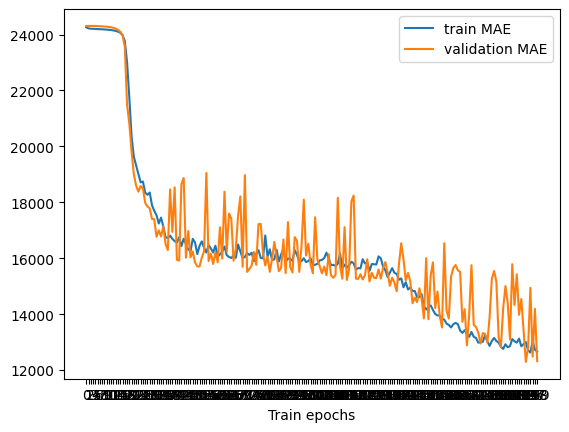

Training MAE Score: 12661.9775
Validation MAE Score: 12316.8965


In [28]:
# Manually tuned neural network using validation metrics
tf.keras.backend.clear_session()
np.random.seed(0)
tf.random.set_seed(0)

NN_num = train_and_evaluate(hidden_layer_sizes = [128, 64, 32], activation = 'relu', optimizer = 'Adam', learning_rate = 0.0005,
                   metric = ['mean_squared_error', 'mean_absolute_error', 'r2_score'], num_epochs = 200)

In [29]:
# Evaluate neural network on validation dataset
NN_num_pred_val = NN_num.predict(X_val_num)
NN_num_eval_val = evaluate_model(y_val, NN_num_pred_val, "")
print('Validation evaluation:', NN_num_eval_val)

# Evaluate neural network on testing dataset
NN_num_pred = NN_num.predict(X_test_num)
NN_num_eval = evaluate_model(y_test, NN_num_pred, "")
print('Testing evaluation:', NN_num_eval)

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Validation evaluation: {'Model': '', 'MAE': 12316.8974609375, 'RMSE': np.float64(32452.108221192655), 'R2': 0.3240875005722046}
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Testing evaluation: {'Model': '', 'MAE': 12063.888671875, 'RMSE': np.float64(31701.73194006914), 'R2': 0.3508407473564148}


## 4. Neural Network on All Variables

In [30]:
def build_model(feature_len,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='metric'):
    """Build a linear regression model using Keras.

    Args:
    features: Number of input features in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    # Build a multiclass logistic regression model
    model = tf.keras.Sequential()

    # Create input layer
    model.add(tf.keras.layers.Input(shape = (feature_len, ), name = 'Input'))

    # Create hidden layers as specified
    for i in range(len(hidden_layer_sizes)):
        model.add(tf.keras.layers.Dense(units = hidden_layer_sizes[i], 
                                        activation = activation,
                                        name = f'layer{i}'
                                       ))

    # Create output layer
    model.add(tf.keras.layers.Dense(units = 1,
                             use_bias = True,
                             activation = 'linear',
                             kernel_initializer = tf.initializers.RandomNormal(stddev = 0.01),
                             bias_initializer = tf.initializers.RandomNormal(stddev = 0.01),
                             name = 'Output'
                            ))

    # Check if have Adam optimizer otherwise use SGD
    if (optimizer == 'Adam'):
        optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate = learning_rate)
        
    # Compile model with specified optimizer, learning rate, and metrics
    model.compile(loss = tf.keras.losses.MeanAbsoluteError(),
                  optimizer = optimizer,
                  metrics = [metric]
                 )

    return model

In [31]:
def train_and_evaluate2(feature_len=X_train.shape[1],
                        hidden_layer_sizes=[],
                        activation='relu',
                        optimizer='SGD',
                        learning_rate=0.01,
                        metric=['mean_squared_error'],
                        num_epochs=10,
                        validation_data = (X_val, y_val)):

  # Build the model.
    model = build_model(feature_len=feature_len,
                        hidden_layer_sizes=hidden_layer_sizes,
                        activation=activation,
                        optimizer=optimizer,
                        metric=metric,
                        learning_rate=learning_rate)

    # Train the model.
    print('Training the model...')
    history = model.fit(
        x=X_train,
        y=y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=validation_data,
        verbose=0)

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_score = history.history['mean_absolute_error']
    val_score = history.history['val_mean_absolute_error']
    plt.plot(train_score, label='train MAE')
    plt.plot(val_score, label='validation MAE')
    plt.xticks(range(num_epochs))
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training MAE Score: %1.4f' %train_score[-1])
    print('Validation MAE Score: %1.4f' %val_score[-1])
    
    return model

Training the model...


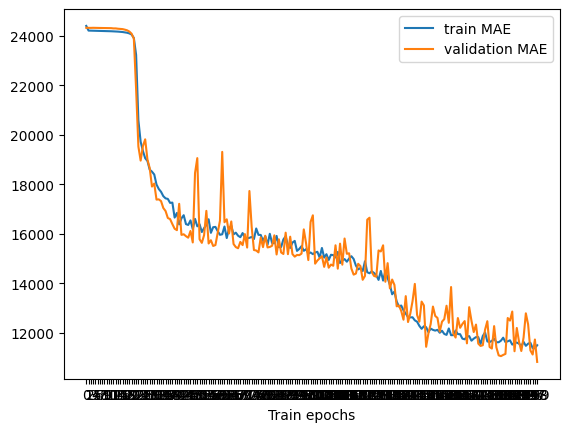

Training MAE Score: 11499.4229
Validation MAE Score: 10824.3398


In [32]:
# Manually tuned neural network using validation metrics 
tf.keras.backend.clear_session()
np.random.seed(0)
tf.random.set_seed(0)

NN_full = train_and_evaluate2(hidden_layer_sizes = [256, 128, 64, 32, 16], activation = 'relu', optimizer = 'Adam', learning_rate = 0.0002,
                   metric = ['mean_squared_error', 'mean_absolute_error', 'r2_score'], num_epochs = 200)

In [33]:
# Evaluate full Neural Network on validation dataset
NN_full_pred_val = NN_full.predict(X_val)
NN_full_eval_val = evaluate_model(y_val, NN_full_pred_val, "")
print('Validation evaluation:', NN_full_eval_val)

# Evaluate full Neural Network on validation dataset
NN_full_pred = NN_full.predict(X_test)
NN_full_eval = evaluate_model(y_test, NN_full_pred, "")
print('Testing evaluation:', NN_full_eval)

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Validation evaluation: {'Model': '', 'MAE': 10824.341796875, 'RMSE': np.float64(29336.645752369168), 'R2': 0.4476357698440552}
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Testing evaluation: {'Model': '', 'MAE': 10793.7021484375, 'RMSE': np.float64(29038.200495209752), 'R2': 0.4553409814834595}


## 5. Subgroup Analysis by Home Prices

In [34]:
# Define home price groups on testing data
X_test_low = X_test.iloc[X_test['zillow_home_value_imputed'] < 5e5]
X_test_mid = X_test.iloc[(5e5 <= X_test['zillow_home_value_imputed']) & (X_test['zillow_home_value_imputed'] < 1e6)]
X_test_high = X_test.iloc[(1e6 <= X_test['zillow_home_value_imputed']) & (X_test['zillow_home_value_imputed'] < 2e6)]
X_test_top = X_test.iloc[(2e6 <= X_test['zillow_home_value_imputed'])]

In [35]:
# Print number of homes in each pricing group
print('Low price home count:', X_test_low.shape[0])
print('Medium price home count:', X_test_mid.shape[0])
print('High price home count:', X_test_high.shape[0])
print('Top price home count:', X_test_top.shape[0])

Low price home count: 62
Medium price home count: 1824
High price home count: 3179
Top price home count: 379


In [36]:
# Split testing outcome data by home price groups
y_test_low = y_test.loc[X_test_low.index]
y_test_mid = y_test.loc[X_test_mid.index]
y_test_high = y_test.loc[X_test_high.index]
y_test_top = y_test.loc[X_test_top.index]

# Predict prices using neural network trained on all features for each price group
NN_full_pred_low = NN_full.predict(X_test_low)
NN_full_pred_mid = NN_full.predict(X_test_mid)
NN_full_pred_high = NN_full.predict(X_test_high)
NN_full_pred_top = NN_full.predict(X_test_top)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [37]:
# Print model evaluation for each pricing subgroup
print('Low Pricing:')
eval_low = evaluate_model(y_test_low, NN_full_pred_low, "")
print(eval_low)

print('Medium Pricing:')
eval_mid = evaluate_model(y_test_mid, NN_full_pred_mid, "")
print(eval_mid)

print('High Pricing:')
eval_high = evaluate_model(y_test_high, NN_full_pred_high, "")
print(eval_high)

print('Top Pricing:')
eval_top = evaluate_model(y_test_top, NN_full_pred_top, "")
print(eval_top)


Low Pricing:
{'Model': '', 'MAE': 18760.16796875, 'RMSE': np.float64(29371.86572214983), 'R2': 0.30452942848205566}
Medium Pricing:
{'Model': '', 'MAE': 8104.291015625, 'RMSE': np.float64(14445.752870653714), 'R2': 0.7521790862083435}
High Pricing:
{'Model': '', 'MAE': 8853.18359375, 'RMSE': np.float64(17344.830238431277), 'R2': 0.8347738981246948}
Top Pricing:
{'Model': '', 'MAE': 38710.515625, 'RMSE': np.float64(91886.89534422196), 'R2': -2.4710612297058105}
